# Analiza sieciowa scenariusza filmowego

## Wersja studencka: od promptu do działającego kodu

Ten notatnik jest szablonem do pracy w Google Colab na zajęciach z humanistyki cyfrowej. Nie zawiera gotowych rozwiązań. Zamiast tego prowadzi Cię przez serię małych promptów, które możesz przekazać modelowi AI, a następnie wkleić wygenerowany kod do pustej komórki.

Efektem końcowym będzie:
1. pobranie i oczyszczenie tekstu scenariusza,
2. wydzielenie scen i postaci,
3. zbudowanie tabeli współwystąpień,
4. narysowanie sieci relacji,
5. zapisanie plików do dalszej analizy.

Wersja z wcześniejszymi rozwiązaniami została zachowana w pliku `analiza_sieciowa_scenariusza_prowadzacy.ipynb`.


## Jak pracować z tym notatnikiem

1. Zmień adres scenariusza w komórce parametru.
2. Skopiuj prompt z bieżącego kroku do modelu AI.
3. Wklej otrzymany kod do pustej komórki pod promptem.
4. Uruchom kod i porównaj rezultat z sekcją **Po uruchomieniu powinieneś zobaczyć**.
5. Jeśli wynik nie zgadza się z opisem, popraw tylko bieżący krok.
6. Dopiero po uzyskaniu poprawnego wyniku przejdź dalej.

W każdym kroku skupiamy się na jednym małym zadaniu. Nie próbuj rozwiązywać kilku etapów naraz. Najważniejszy wynik każdego kroku powinien pozostać dostępny do następnego kroku, ale to model ma zdecydować, jak to zorganizować w kodzie.


## Parametr startowy

To jedyna komórka, którą zmieniasz ręcznie przed rozpoczęciem pracy. Wybierz adres strony scenariusza z IMSDb.


In [1]:
# Jedyny parametr, który zmieniasz w tym notatniku
adres_scenariusza = "https://imsdb.com/scripts/Mulholland-Drive.html"


In [2]:
adres_scenariusza

'https://imsdb.com/scripts/Mulholland-Drive.html'

---
## Etap 1: Od strony internetowej do czystego tekstu

Najpierw upewniamy się, że pracujemy na właściwej stronie i że potrafimy oddzielić tekst scenariusza od pozostałych elementów witryny.


### Krok 1A. Pobranie strony i kontrola surowej odpowiedzi

#### Cel i sens analityczny

Zanim zaczniemy analizować scenariusz, trzeba potwierdzić, że wskazany adres rzeczywiście prowadzi do strony z treścią, na której da się pracować dalej.


#### Prompt dla modelu

```text
Kontekst:
Chcesz sprawdzić, czy adres podany w komórce parametru rzeczywiście prowadzi do strony ze scenariuszem filmowym.

Wejście:
Adres scenariusza zapisany w pierwszej komórce parametru.

Zadanie:
Pobierz zawartość tej strony i przygotuj krótki podgląd surowej odpowiedzi. Zachowaj pobraną treść tak, aby można było wykorzystać ją w następnym kroku bez ponownego pobierania.

Pokaż wynik:
- komunikat, czy pobranie się udało,
- końcowy adres strony po ewentualnym przekierowaniu,
- pierwsze 8-10 niepustych linii pobranej treści.

Warunek poprawności:
W wyniku powinny być widoczne elementy strony internetowej, a treść nie może być pusta.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy adresu, braku połączenia albo pustej odpowiedzi.

Nie rób jeszcze:
Nie wydobywaj tekstu scenariusza i nie analizuj jego struktury.
```


In [3]:
import requests

try:
    # Pobieranie zawartości strony
    response = requests.get(adres_scenariusza)
    response.raise_for_status()

    # Zachowanie treści do następnego kroku
    surowa_tresc = response.text

    # Przygotowanie wyniku
    print("✅ Pobranie strony zakończone sukcesem.")
    print(f"📍 Końcowy adres: {response.url}")
    print("\n--- Podgląd pierwszych niepustych linii ---")

    linie = [line.strip() for line in surowa_tresc.splitlines() if line.strip()]
    for linia in linie[:10]:
        print(linia)

except requests.exceptions.MissingSchema:
    print("❌ Błąd: Nieprawidłowy format adresu (brak http/https).")
except requests.exceptions.ConnectionError:
    print("❌ Błąd: Problem z połączeniem internetowym.")
except requests.exceptions.HTTPError as e:
    print(f"❌ Błąd HTTP: {e}")
except Exception as e:
    print(f"❌ Wystąpił nieoczekiwany błąd: {e}")

✅ Pobranie strony zakończone sukcesem.
📍 Końcowy adres: https://imsdb.com/scripts/Mulholland-Drive.html

--- Podgląd pierwszych niepustych linii ---
<html>
<head>
<!-- Google tag (gtag.js) -->
<script async src="https://www.googletagmanager.com/gtag/js?id=G-W5BXG8HCH3"></script>
<script>
window.dataLayer = window.dataLayer || [];
function gtag(){dataLayer.push(arguments);}
gtag('js', new Date());
gtag('config', 'G-W5BXG8HCH3');
</script>


#### Po uruchomieniu powinieneś zobaczyć


- Krótki komunikat potwierdzający, że strona została pobrana albo czytelne wyjaśnienie problemu.
- Końcowy adres strony, jeśli po drodze nastąpiło przekierowanie.
- Fragment surowej treści, który wygląda jak pełna strona internetowa, a nie jak pusty wynik.


### Krok 1B. Wydobycie właściwego tekstu scenariusza

#### Cel i sens analityczny

Strona zawiera menu, linki i elementy pomocnicze. Do dalszej analizy potrzebny jest tylko właściwy tekst scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Surowa strona zawiera dużo elementów, które nie należą do scenariusza.

Wejście:
Pobrana treść strony z poprzedniego kroku.

Zadanie:
Wydobądź tylko właściwy tekst scenariusza i odrzuć menu, nagłówki, stopki, linki i inne elementy witryny. Zachowaj oczyszczony tekst tak, aby był dostępny w następnym kroku.

Pokaż wynik:
- krótki komunikat, że tekst scenariusza został odnaleziony,
- pierwsze 15 niepustych linii oczyszczonego tekstu.

Warunek poprawności:
W podglądzie powinien być widoczny układ scenariusza lub dialogów, a nie nawigacja strony.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się odnaleźć głównego bloku z tekstem scenariusza albo że wynik nadal zawiera zbyt dużo treści pobocznych.

Nie rób jeszcze:
Nie licz znaków i nie rozpoznawaj scen ani postaci.
```


In [4]:
from bs4 import BeautifulSoup

try:
    # Parsowanie surowej treści HTML
    soup = BeautifulSoup(surowa_tresc, 'html.parser')

    # Na IMSDb scenariusz zazwyczaj znajduje się wewnątrz tagu <pre>
    script_block = soup.find('pre')

    if script_block:
        # Wyodrębnienie czystego tekstu i zachowanie go do następnego kroku
        tekst_scenariusza = script_block.get_text()

        print("✅ Tekst scenariusza został pomyślnie odnaleziony.")
        print("\n--- Podgląd pierwszych 15 niepustych linii ---")

        # Wyświetlenie pierwszych 15 niepustych linii dla kontroli
        linie_scenariusza = [line for line in tekst_scenariusza.splitlines() if line.strip()]
        for linia in linie_scenariusza[:15]:
            print(linia)
    else:
        print("❌ Nie udało się odnaleźć głównego bloku z tekstem scenariusza (brak tagu <pre>).")

except Exception as e:
    print(f"❌ Wystąpił błąd podczas przetwarzania tekstu: {e}")

✅ Tekst scenariusza został pomyślnie odnaleziony.

--- Podgląd pierwszych 15 niepustych linii ---
Mulholland Drive Screenplay
			M  U  L  H  O  L  L  A  N  D
				D  R  I  V  E    
				 1/5/1999
		M U L H 0 L L A N D             D R I V E
EXT.  NIGHT - HOLLYWOOD HILLS, LOS ANGELES
Darkness. Distant sounds of freeway traffic. Then the closer
sound of a car - its headlights illumine an oleander bush and
the limbs of an Eucalyptus tree. Then the headlights turn - a
street sign is suddenly brightly lit. The words on the sign
read... "Mulholland Drive." The car moves under the sign as
it turns and the words fall once again into darkness.
							CUT TO:
EXT. NIGHT - MULHOLLAND DRIVE
Gliding we follow the car - an older black Cadillac limousine


#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie, że udało się odseparować właściwy tekst scenariusza.
- Kilkanaście pierwszych linii przypominających zapis scenariusza filmowego.
- Brak widocznego menu, stopki i innych elementów witryny.


### Krok 1C. Podgląd tekstu i szybka kontrola jakości

#### Cel i sens analityczny

Zanim przejdziemy dalej, warto upewnić się, że tekst scenariusza jest wystarczająco długi i wygląda wiarygodnie.


#### Prompt dla modelu

```text
Kontekst:
Przed analizą scen i postaci trzeba sprawdzić, czy oczyszczony tekst wygląda kompletnie.

Wejście:
Oczyszczony tekst scenariusza z poprzedniego kroku.

Zadanie:
Pokaż krótki podgląd tekstu oraz podstawowe informacje o jego rozmiarze. Jeśli tekst wygląda podejrzanie krótko albo zawiera głównie elementy witryny, wypisz ostrzeżenie. Zachowaj tekst do dalszej analizy.

Pokaż wynik:
- liczbę znaków,
- liczbę linii,
- fragment początku tekstu o długości mniej więcej 1000-1500 znaków.

Warunek poprawności:
Podgląd powinien przypominać początek scenariusza, a nie przypadkowy fragment strony internetowej.

Jeśli wystąpi błąd:
Wyświetl informację, że tekst jest pusty, zbyt krótki albo nadal wymaga oczyszczenia.

Nie rób jeszcze:
Nie rozpoznawaj scen i postaci.
```


In [5]:
try:
    # Sprawdzenie czy zmienna tekst_scenariusza istnieje
    if 'tekst_scenariusza' not in locals() or not tekst_scenariusza.strip():
        print("❌ Błąd: Tekst scenariusza jest pusty lub nie został poprawnie przekazany z poprzedniego kroku.")
    else:
        liczba_znakow = len(tekst_scenariusza)
        linie_scenariusza = tekst_scenariusza.splitlines()
        liczba_linii = len(linie_scenariusza)

        print(f"📊 Statystyki tekstu:")
        print(f"- Liczba znaków: {liczba_znakow}")
        print(f"- Liczba linii: {liczba_linii}")

        # Ostrzeżenie o długości
        if liczba_znakow < 5000:
            print("⚠️ OSTRZEŻENIE: Tekst wydaje się podejrzanie krótki. Sprawdź, czy Krok 1B przebiegł poprawnie.")

        print("\n--- Podgląd początku scenariusza (ok. 1500 znaków) ---")
        print(tekst_scenariusza[:1500])

        if liczba_znakow > 1500:
            print("\n[...] (ciąg dalszy następuje)")

except Exception as e:
    print(f"❌ Wystąpił błąd podczas analizy tekstu: {e}")

📊 Statystyki tekstu:
- Liczba znaków: 133128
- Liczba linii: 4918

--- Podgląd początku scenariusza (ok. 1500 znaków) ---



Mulholland Drive Screenplay



			M  U  L  H  O  L  L  A  N  D

				D  R  I  V  E    












				 1/5/1999
    




		M U L H 0 L L A N D             D R I V E
    

EXT.  NIGHT - HOLLYWOOD HILLS, LOS ANGELES
    
Darkness. Distant sounds of freeway traffic. Then the closer
sound of a car - its headlights illumine an oleander bush and
the limbs of an Eucalyptus tree. Then the headlights turn - a
street sign is suddenly brightly lit. The words on the sign
read... "Mulholland Drive." The car moves under the sign as
it turns and the words fall once again into darkness.
    
							CUT TO:
    
EXT. NIGHT - MULHOLLAND DRIVE
    
Gliding we follow the car - an older black Cadillac limousine
- as it winds its way up Mulholland Drive through the
darkness of the Hollywood Hills. There is no one else on the
road. As we drift closer to the car...
    
							CUT TO:
 

#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość materiału: znaki i linie.
- Dłuższy fragment początku scenariusza, który da się ocenić wzrokowo.
- W razie problemu: ostrzeżenie, że materiał nie nadaje się jeszcze do dalszych kroków.


#### Prompt dla modelu

```text
Kontekst:
Przed analizą scen i postaci trzeba sprawdzić, czy oczyszczony tekst wygląda kompletnie.

Wejście:
Oczyszczony tekst scenariusza z poprzedniego kroku.

Zadanie:
Pokaż krótki podgląd tekstu oraz podstawowe informacje o jego rozmiarze. Jeśli tekst wygląda podejrzanie krótko albo zawiera głównie elementy witryny, wypisz ostrzeżenie. Zachowaj tekst do dalszej analizy.

Pokaż wynik:
- liczbę znaków,
- liczbę linii,
- fragment początku tekstu o długości mniej więcej 1000-1500 znaków.

Warunek poprawności:
Podgląd powinien przypominać początek scenariusza, a nie przypadkowy fragment strony internetowej.

Jeśli wystąpi błąd:
Wyświetl informację, że tekst jest pusty, zbyt krótki albo nadal wymaga oczyszczenia.

Nie rób jeszcze:
Nie rozpoznawaj scen i postaci.
```


---
## Etap 2: Rozpoznanie struktury scenariusza

W tym etapie przechodzimy od ciągłego tekstu do uporządkowanej struktury: najpierw sceny, potem postacie, a na końcu pełna lista scen z przypisanymi bohaterami.


### Krok 2A. Wykrycie granic scen

#### Cel i sens analityczny

Scena jest podstawową jednostką analizy sieciowej. Najpierw musimy odnaleźć miejsca, w których scenariusz przechodzi do nowej sceny.


#### Prompt dla modelu

```text
Kontekst:
W scenariuszach filmowych nowe sceny są zwykle otwierane krótkimi nagłówkami opisującymi miejsce i czas akcji, często zaczynającymi się od skrótów oznaczających wnętrze lub plener.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Wykryj granice scen i zbuduj uporządkowaną listę scen z numerami oraz nagłówkami. Zachowaj ten wynik do kolejnego kroku.

Pokaż wynik:
- łączną liczbę rozpoznanych scen,
- pierwszych 8 rekordów w formie `numer sceny | nagłówek sceny`.

Warunek poprawności:
Nagłówki powinny wyglądać jak opisy miejsca i czasu akcji, a nie jak dialog lub didaskalia. Jeśli scenariusz ma niestandardowy zapis, krótko opisz przyjętą zasadę rozpoznawania scen.

Jeśli wystąpi błąd:
Wyjaśnij, że nie udało się znaleźć wyraźnych granic scen albo że wykryte nagłówki są zbyt niejednoznaczne.

Nie rób jeszcze:
Nie przypisuj postaci do scen.
```


In [6]:
import re

try:
    if 'tekst_scenariusza' not in locals():
        print("❌ Błąd: Brak tekstu scenariusza. Uruchom poprzednie kroki.")
    else:
        # Poprawiony wzorzec: szukamy linii zaczynających się od INT lub EXT
        # Dodajemy wymóg, by przed nimi nie było zbyt wielu spacji (zwykle nagłówki są przy lewym marginesie)
        wzorzec_sceny = re.compile(r'^[ ]{0,4}(?:INT\.?/EXT\.?|EXT\.?/INT\.?|INT\.|EXT\.)[ ].+$', re.MULTILINE | re.IGNORECASE)

        # Znalezienie dopasowań
        dopasowania = wzorzec_sceny.findall(tekst_scenariusza)

        # Oczyszczenie i odfiltrowanie krótkich linii
        sceny_lista = [d.strip() for d in dopasowania if len(d.strip()) > 5]

        if not sceny_lista:
            print("❌ Nie udało się znaleźć granic scen. Sprawdź formatowanie tekstu.")
        else:
            print(f"✅ Wykryto łącznie {len(sceny_lista)} scen.")
            print("\n--- Pierwszych 15 rozpoznanych scen (podgląd) ---")
            print(f"{'Nr':<5} | {'Nagłówek sceny'}")
            print("-" * 50)

            for i, naglowek in enumerate(sceny_lista[:15], 1):
                print(f"{i:<5} | {naglowek}")

except Exception as e:
    print(f"❌ Wystąpił błąd: {e}")

✅ Wykryto łącznie 94 scen.

--- Pierwszych 15 rozpoznanych scen (podgląd) ---
Nr    | Nagłówek sceny
--------------------------------------------------
1     | EXT.  NIGHT - HOLLYWOOD HILLS, LOS ANGELES
2     | EXT. NIGHT - MULHOLLAND DRIVE
3     | INT. BLACK CADILLAC LIMOUSINE - NIGHT
4     | EXT.  FURTHER UP MULHOLLAND DRIVE - NIGHT
5     | INT. EXT. - CADILLAC LIMOUSINE
6     | EXT. HOLLYWOOD HILLS - LATER - NIGHT
7     | EXT. HOLLYWOOD STREETS - LATER - NIGHT
8     | EXT. HOLLYWOOD STREETS - LATER - NIGHT
9     | EXT.  MULHOLLAND DRIVE   - NIGHT
10    | EXT. HOLLYWOOD STREETS - EARLY DAWN
11    | INT. APARTMENT - EARLY DAWN
12    | INT. DENNY'S RESTAURANT , HOLLYWOOD - MORNING
13    | EXT. DENNY'S
14    | EXT.  LAX AIRPORT - DAY
15    | INT. LAX AIRPORT


#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen rozpoznanych w całym tekście.
- Krótką listę pierwszych nagłówków, które wyglądają jak kolejne miejsca lub momenty akcji.
- Ewentualną krótką notatkę, jeśli scenariusz używa nietypowego formatu nagłówków.


### Krok 2B. Wykrycie kandydatów na nazwy postaci

#### Cel i sens analityczny

Sieć relacji budujemy z udziałem postaci, więc trzeba najpierw odróżnić ich nazwy od innych elementów zapisu scenariusza.


#### Prompt dla modelu

```text
Kontekst:
Nazwy postaci w scenariuszach często są zapisane wielkimi literami, wyraźnie odsunięte od lewego marginesu i czasem mają dopiski w nawiasach, które trzeba usunąć.

Wejście:
Oczyszczony tekst scenariusza.

Zadanie:
Znajdź kandydatów na nazwy postaci, oczyść je z dopisków w nawiasach i odfiltruj oczywiste instrukcje reżyserskie, przejścia montażowe oraz inne elementy, które nie są postaciami. Zachowaj wynik do kolejnego kroku.

Pokaż wynik:
- liczbę unikalnych kandydatów po oczyszczeniu,
- próbkę 20 rekordów w formie `oryginalny zapis | oczyszczona nazwa`.

Warunek poprawności:
Na liście powinny dominować imiona lub nazwy postaci, a nie komendy typu przejście, opis kamery albo tytuł karty.

Jeśli wystąpi błąd:
Pokaż kilka problematycznych przykładów i krótko wyjaśnij, dlaczego trudno je rozstrzygnąć.

Nie rób jeszcze:
Nie przypisuj postaci do konkretnych scen.
```


In [7]:
import re
from collections import Counter

try:
    if 'tekst_scenariusza' not in locals():
        print("❌ Błąd: Brak tekstu scenariusza. Uruchom poprzednie kroki.")
    else:
        # Lista wykluczeń technicznych
        wykluczenia = {'INT.', 'EXT.', 'CUT TO:', 'FADE IN:', 'FADE OUT:', 'CONTINUED', 'THE END', 'TRANSITION', 'TITLE', 'MONTAGE', 'DISSOLVE TO:', 'BACK TO:', 'PROLOGUE', 'SCENE', 'VOICE', 'DRIVE', 'CUT', 'DISSOLVE', 'O.K.'}

        # Powrót do mniejszego wcięcia (min. 4), ale zachowanie rygoru 3 liter
        wzorzec_postaci = re.compile(r'^[ \t]{4,}([A-Z][A-Z\s\-0-9\.\']+)(?=\s|\(|$)', re.MULTILINE)

        znaleziska = wzorzec_postaci.findall(tekst_scenariusza)

        postacie_mapa = {}
        unikalne_set = set()

        for raw_name in znaleziska:
            # 1. Usuwanie nawiasów
            name = re.sub(r'\(.*?\)', '', raw_name)

            # 2. Usuwanie wielokropków i interpunkcji
            name = name.replace("...", "").replace("..", "").replace(".", " ")

            # 3. Normalizacja spacji
            name = " ".join(name.split()).strip()

            # 4. Liczenie PRAWDZIWYCH LITER (tylko A-Z)
            tylko_litery = re.sub(r'[^A-Z]', '', name.upper())

            # Warunki poprawności:
            # - minimum 3 LITERY (np. DAN - tak, D.. - nie, I - nie)
            # - nie jest na liście wykluczeń
            # - nie jest nagłówkiem sceny
            if (len(tylko_litery) >= 3
                and name.upper() not in wykluczenia
                and not name.startswith(('INT', 'EXT', 'FADE'))):

                postacie_mapa[raw_name.strip()] = name
                unikalne_set.add(name)

        lista_postaci_global = sorted(list(unikalne_set))

        if not lista_postaci_global:
            print("⚠️ Nie znaleziono postaci spełniających kryterium minimum 3 liter.")
        else:
            print(f"✅ Znaleziono {len(lista_postaci_global)} unikalnych postaci.")
            print("\n--- Podgląd 40 rekordów (oryginał | oczyszczona nazwa) ---")

            pokazane = 0
            for k, v in postacie_mapa.items():
                if pokazane < 40:
                    print(f"{k:<35} | {v}")
                    pokazane += 1
                else: break

except Exception as e:
    print(f"❌ Wystąpił błąd podczas przetwarzania postaci: {e}")

✅ Znaleziono 78 unikalnych postaci.

--- Podgląd 40 rekordów (oryginał | oczyszczona nazwa) ---
D  R  I  V  E                       | D R I V E
DARK-HAIRED WOMAN                   | DARK-HAIRED WOMAN
DRIVER                              | DRIVER
DETECTIVE HARRY MCKNIGHT            | DETECTIVE HARRY MCKNIGHT
DETECTIVE NEAL DOMGAARD             | DETECTIVE NEAL DOMGAARD
HERB                                | HERB
DAN
		I                            | DAN I
DAN                                 | DAN
OLD LADY                            | OLD LADY
BETTY                               | BETTY
IRENE                               | IRENE
CAB DRIVER                          | CAB DRIVER
MANAGER                             | MANAGER
BETTY
		I                          | BETTY I
MRS. LANOIS                         | MRS LANOIS
COCO
		I                           | COCO I
COCO                                | COCO
BETTY
		I...
    
				COCO       | BETTY I COCO
DARK-HAIRED WOMAN
		A              | DARK-H

#### Po uruchomieniu powinieneś zobaczyć


- Liczbę rozpoznanych nazw po oczyszczeniu.
- Próbkę zapisów pokazującą, jak surowe nazwy zostały uproszczone do postaci możliwych do porównywania.
- Brak dominacji elementów technicznych scenariusza nad rzeczywistymi postaciami.


### Krok 2C. Zbudowanie listy scen z postaciami

#### Cel i sens analityczny

Dopiero po połączeniu scen i postaci otrzymujemy strukturę, z której można obliczać współwystąpienia.


#### Prompt dla modelu

```text
Kontekst:
Masz już rozpoznane granice scen oraz kandydatów na nazwy postaci.

Wejście:
Wynik kroku z granicami scen i wynik kroku z rozpoznanymi postaciami.

Zadanie:
Zbuduj finalną listę scen. Każda scena ma zawierać numer, nagłówek oraz zbiór unikalnych postaci obecnych w tej scenie. Jeśli w danej scenie nie uda się rozpoznać żadnej postaci, zaznacz to jasno. Zachowaj listę scen do dalszych obliczeń.

Pokaż wynik:
- łączną liczbę scen,
- 5 przykładowych rekordów w formie `numer sceny | nagłówek | postacie`.

Warunek poprawności:
Ta sama postać nie powinna być powtórzona kilka razy w obrębie jednej sceny.

Jeśli wystąpi błąd:
Wyświetl krótką informację, czy problem dotyczy scen bez postaci, czy niespójności między wcześniejszymi krokami.

Nie rób jeszcze:
Nie buduj jeszcze rankingu postaci ani relacji między nimi.
```


In [8]:
try:
    if 'tekst_scenariusza' not in locals() or 'sceny_lista' not in locals() or 'lista_postaci_global' not in locals():
        print("❌ Błąd: Brak wymaganych danych z poprzednich kroków.")
    else:
        # Przygotowanie listy scen z przypisanymi postaciami
        finalna_lista_scen = []

        # Tworzymy listę pozycji nagłówków w tekście
        pozycje_naglowkow = []
        for naglowek in sceny_lista:
            idx = tekst_scenariusza.find(naglowek)
            if idx != -1:
                pozycje_naglowkow.append((idx, naglowek))

        # Sortujemy pozycje (na wypadek, gdyby find zwrócił inną kolejność)
        pozycje_naglowkow.sort()

        # Dzielimy tekst na fragmenty (od jednego nagłówka do drugiego)
        for i in range(len(pozycje_naglowkow)):
            start_idx = pozycje_naglowkow[i][0]
            naglowek = pozycje_naglowkow[i][1]

            if i < len(pozycje_naglowkow) - 1:
                end_idx = pozycje_naglowkow[i+1][0]
            else:
                end_idx = len(tekst_scenariusza)

            fragment_sceny = tekst_scenariusza[start_idx:end_idx]

            # Wyszukiwanie postaci z listy globalnej w danym fragmencie
            postacie_w_scenie = set()
            for postac in lista_postaci_global:
                # Szukamy postaci jako samodzielnego słowa w tekście (nie fragmentu innego słowa)
                if re.search(r'\b' + re.escape(postac) + r'\b', fragment_sceny):
                    postacie_w_scenie.add(postac)

            finalna_lista_scen.append({
                'numer': i + 1,
                'naglowek': naglowek,
                'postacie': sorted(list(postacie_w_scenie))
            })

        print(f"✅ Przetworzono łącznie {len(finalna_lista_scen)} scen.")
        print("\n--- Przykładowe 20 rekordów ---")
        print(f"{'Nr':<4} | {'Nagłówek':<40} | {'Postacie'}")
        print("-" * 80)

        for scena in finalna_lista_scen[:20]:
            postacie_str = ", ".join(scena['postacie']) if scena['postacie'] else "[Brak postaci]"
            print(f"{scena['numer']:<4} | {scena['naglowek'][:40]:<40} | {postacie_str}")

        sceny_bez_postaci = sum(1 for s in finalna_lista_scen if not s['postacie'])
        if sceny_bez_postaci > 0:
            print(f"\nℹ️ Uwaga: W {sceny_bez_postaci} scenach nie wykryto żadnej postaci z listy.")

except Exception as e:
    print(f"❌ Wystąpił błąd podczas budowania listy scen: {e}")

✅ Przetworzono łącznie 94 scen.

--- Przykładowe 20 rekordów ---
Nr   | Nagłówek                                 | Postacie
--------------------------------------------------------------------------------
1    | EXT.  NIGHT - HOLLYWOOD HILLS, LOS ANGEL | [Brak postaci]
2    | EXT. NIGHT - MULHOLLAND DRIVE            | [Brak postaci]
3    | INT. BLACK CADILLAC LIMOUSINE - NIGHT    | DARK-HAIRED WOMAN, DRIVER
4    | EXT.  FURTHER UP MULHOLLAND DRIVE - NIGH | [Brak postaci]
5    | INT. EXT. - CADILLAC LIMOUSINE           | [Brak postaci]
6    | EXT. HOLLYWOOD HILLS - LATER - NIGHT     | [Brak postaci]
7    | EXT. HOLLYWOOD STREETS - LATER - NIGHT   | [Brak postaci]
8    | EXT. HOLLYWOOD STREETS - LATER - NIGHT   | [Brak postaci]
9    | EXT.  MULHOLLAND DRIVE   - NIGHT         | DETECTIVE HARRY MCKNIGHT, DETECTIVE NEAL DOMGAARD
10   | EXT. HOLLYWOOD STREETS - EARLY DAWN      | [Brak postaci]
11   | INT. APARTMENT - EARLY DAWN              | [Brak postaci]
12   | INT. DENNY'S RESTAURANT , H

#### Po uruchomieniu powinieneś zobaczyć


- Liczbę scen gotowych do dalszej analizy.
- Pięć czytelnych rekordów pokazujących numer sceny, jej nagłówek i listę rozpoznanych postaci.
- Jasną informację, jeśli część scen pozostała bez przypisanych postaci.


---
## Etap 3: Które postacie są najważniejsze?

Zanim zbudujemy sieć relacji, sprawdzamy rozkład obecności postaci w scenach. To prosty, ale bardzo użyteczny punkt wyjścia do interpretacji.


### Krok 3A. Ranking postaci według liczby scen

#### Cel i sens analityczny

Liczba scen, w których pojawia się dana postać, daje pierwszą miarę jej znaczenia w strukturze narracji.


#### Prompt dla modelu

```text
Kontekst:
Masz listę scen, z których każda zawiera unikalne postacie.

Wejście:
Finalna lista scen z przypisanymi postaciami.

Zadanie:
Policz, w ilu różnych scenach pojawia się każda postać. Posortuj wynik od najwyższego do najniższego. Zachowaj ranking do następnego kroku.

Pokaż wynik:
- łączną liczbę unikalnych postaci,
- tabelę 20 najwyższych wyników w formie `postać | liczba scen`.

Warunek poprawności:
W obrębie jednej sceny dana postać może zostać policzona tylko raz.

Jeśli wystąpi błąd:
Wyświetl informację, że lista scen jest pusta albo że nie udało się rozpoznać postaci w wystarczającej liczbie scen.

Nie rób jeszcze:
Nie rysuj wykresu i nie buduj relacji między postaciami.
```


In [9]:
from collections import Counter

try:
    if 'finalna_lista_scen' not in locals() or not finalna_lista_scen:
        print("❌ Błąd: Lista scen jest pusta lub nie została wygenerowana.")
    else:
        # Liczenie wystąpień każdej postaci w scenach
        licznik_scen_postaci = Counter()

        for scena in finalna_lista_scen:
            for postac in scena['postacie']:
                licznik_scen_postaci[postac] += 1

        # Tworzenie rankingu (lista krotek posortowana malejąco)
        ranking_postaci = licznik_scen_postaci.most_common()

        if not ranking_postaci:
            print("❌ Nie udało się rozpoznać postaci w wystarczającej liczbie scen.")
        else:
            print(f"✅ Znaleziono łącznie {len(ranking_postaci)} unikalnych postaci.")
            print("\n--- Pełna lista postaci (według liczby scen) ---")
            print(f"{'Postać':<35} | {'Liczba scen'}")
            print("-" * 55)

            for postac, liczba in ranking_postaci:
                print(f"{postac:<35} | {liczba}")

            # Zachowanie rankingu do następnego kroku
            ranking_postaci_global = ranking_postaci

except Exception as e:
    print(f"❌ Wystąpił błąd podczas tworzenia rankingu: {e}")

✅ Znaleziono łącznie 54 unikalnych postaci.

--- Pełna lista postaci (według liczby scen) ---
Postać                              | Liczba scen
-------------------------------------------------------
BETTY                               | 29
RITA                                | 17
ADAM                                | 12
COCO                                | 7
DRIVER                              | 4
RAY                                 | 4
GENE                                | 4
LORRAINE                            | 4
DARK-HAIRED WOMAN                   | 3
WILKINS                             | 3
DETECTIVE HARRY MCKNIGHT            | 2
DETECTIVE NEAL DOMGAARD             | 2
DAN                                 | 2
DIANE                               | 2
HERB                                | 2
MANAGER                             | 2
JOE                                 | 2
ROBERT SMITH                        | 2
LIMO DRIVER                         | 2
RECEPTIONIST                        |

#### Po uruchomieniu powinieneś zobaczyć


- Krótką tabelę rankingową z najczęściej występującymi postaciami.
- Łączną liczbę rozpoznanych postaci.
- Wyniki posortowane malejąco według liczby scen.


#### Pytanie interpretacyjne

Które postacie dominują w strukturze scen i czy ten ranking zgadza się z Twoją intuicją o bohaterach filmu?


### Krok 3B. Wykres 10 najczęściej występujących postaci

#### Cel i sens analityczny

Wizualizacja pozwala szybko ocenić, czy scenariusz jest skupiony wokół jednej postaci, czy raczej rozkłada uwagę na kilka figur.


#### Prompt dla modelu

```text
Kontekst:
Masz już gotowy ranking liczby scen przypisanych do postaci.

Wejście:
Ranking postaci z poprzedniego kroku.

Zadanie:
Narysuj czytelny poziomy wykres dla 10 postaci o największej liczbie scen. Dodaj tytuł oraz opisy osi. Zachowaj ranking do dalszej pracy.

Pokaż wynik:
- pojedynczy wykres obejmujący tylko 10 najwyższych wyników,
- czytelne nazwy postaci,
- porządek od najwyższego do najniższego wyniku.

Warunek poprawności:
Jeśli ranking zawiera mniej niż 10 postaci, narysuj tyle, ile jest dostępnych, i wyraźnie to zaznacz.

Jeśli wystąpi błąd:
Wyświetl krótkie wyjaśnienie, dlaczego nie da się przygotować wykresu.

Nie rób jeszcze:
Nie buduj jeszcze relacji współwystąpień.
```


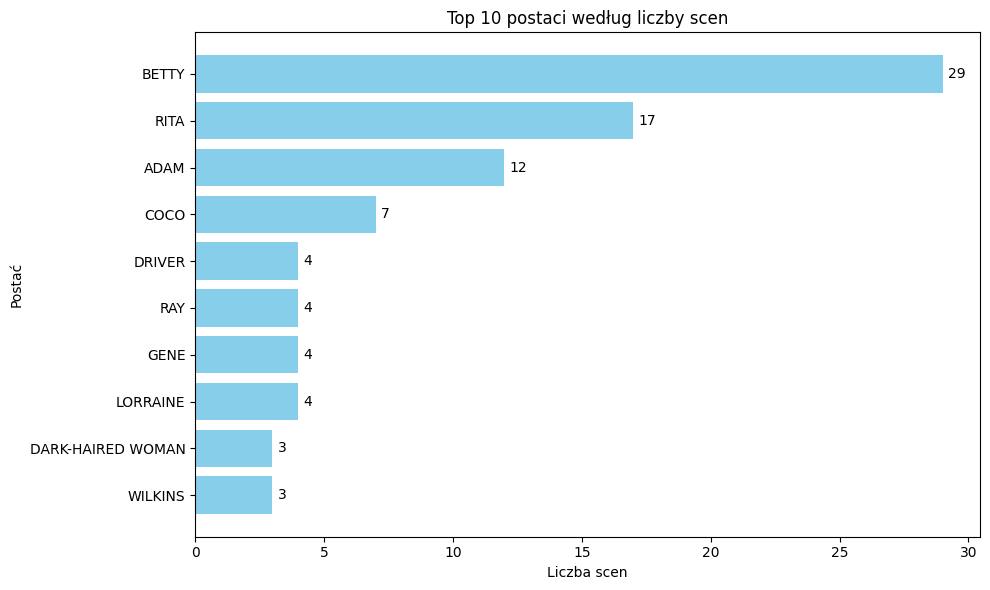

In [10]:
import matplotlib.pyplot as plt

try:
    if 'ranking_postaci_global' not in locals() or not ranking_postaci_global:
        print("❌ Błąd: Brak danych rankingu. Uruchom poprzedni krok.")
    else:
        # Wybór 10 najlepszych wyników (lub wszystkich, jeśli jest ich mniej)
        top_10 = ranking_postaci_global[:10]

        imiona = [item[0] for item in top_10][::-1]  # Odwracamy dla wykresu poziomego
        liczba_scen = [item[1] for item in top_10][::-1]

        # Tworzenie wykresu
        plt.figure(figsize=(10, 6))
        plt.barh(imiona, liczba_scen, color='skyblue')

        # Opisy
        plt.xlabel('Liczba scen')
        plt.ylabel('Postać')
        plt.title('Top 10 postaci według liczby scen')

        # Dodanie etykiet z wartościami na końcach słupków
        for i, v in enumerate(liczba_scen):
            plt.text(v + 0.2, i, str(v), va='center')

        plt.tight_layout()
        plt.show()

        if len(ranking_postaci_global) < 10:
            print(f"ℹ️ Uwaga: Wyświetlono wszystkie dostępne postacie ({len(ranking_postaci_global)}).")

except Exception as e:
    print(f"❌ Wystąpił błąd podczas generowania wykresu: {e}")

#### Po uruchomieniu powinieneś zobaczyć


- Jeden poziomy wykres z nazwami postaci i długościami słupków odpowiadającymi liczbie scen.
- Wyraźny tytuł i podpisane osie.
- Brak dodatkowych elementów, które utrudniałyby szybkie odczytanie rankingu.


#### Pytanie interpretacyjne

Czy rozkład obecności postaci wygląda na skoncentrowany wokół jednej osi fabularnej, czy bardziej rozproszony między kilka ważnych postaci?


---
## Etap 4: Od scen do relacji między postaciami

Tutaj przechodzimy od obecności postaci do ich współwystępowania. To właśnie z tych danych powstanie sieć relacji.


### Krok 4A. Pary współwystąpień wewnątrz pojedynczych scen

#### Cel i sens analityczny

Każda scena z co najmniej dwiema postaciami dostarcza zestawu potencjalnych relacji, które można później zagregować w całym scenariuszu.


#### Prompt dla modelu

```text
Kontekst:
Relacja między dwiema postaciami pojawia się wtedy, gdy obie występują w tej samej scenie.

Wejście:
Lista scen z unikalnymi postaciami.

Zadanie:
Dla każdej sceny wygeneruj wszystkie unikalne pary postaci występujących razem. Zachowaj wynik tak, aby można było później zsumować go dla całego scenariusza.

Pokaż wynik:
- liczbę scen, z których udało się utworzyć przynajmniej jedną parę,
- próbkę 15 wierszy w formie `numer sceny | postać A | postać B`.

Warunek poprawności:
Para nie może łączyć postaci z samą sobą, a ta sama para nie powinna pojawiać się podwójnie w obrębie jednej sceny. Zachowaj stały porządek zapisu par, aby później łatwo je sumować.

Jeśli wystąpi błąd:
Wyjaśnij, czy problem wynika z tego, że sceny mają zbyt mało postaci, czy z niespójności wcześniejszych danych.

Nie rób jeszcze:
Nie sumuj jeszcze wyników dla całego scenariusza.
```


In [11]:
from itertools import combinations

try:
    if 'finalna_lista_scen' not in locals() or not finalna_lista_scen:
        print("❌ Błąd: Brak listy scen z poprzednich kroków.")
    else:
        wszystkie_pary_sceniczne = []
        sceny_z_relacjami = 0

        for scena in finalna_lista_scen:
            postacie = scena['postacie']
            # Relacja zachodzi tylko gdy w scenie są co najmniej 2 postacie
            if len(postacie) >= 2:
                # combinations generuje unikalne pary (A, B)
                # Ponieważ postacie w scenie są już posortowane, pary będą miały stały porządek
                pary = list(combinations(postacie, 2))
                for pA, pB in pary:
                    wszystkie_pary_sceniczne.append({
                        'numer_sceny': scena['numer'],
                        'postac_A': pA,
                        'postac_B': pB
                    })
                sceny_z_relacjami += 1

        if not wszystkie_pary_sceniczne:
            print("⚠️ Nie znaleziono żadnej sceny z co najmniej dwiema postaciami. Nie można utworzyć relacji.")
        else:
            print(f"✅ Wygenerowano pary dla {sceny_z_relacjami} scen.")
            print(f"📊 Łączna liczba surowych powiązań: {len(wszystkie_pary_sceniczne)}")
            print("\n--- Próbka 15 par współwystępujących ---")
            print(f"{'Nr sceny':<8} | {'Postać A':<25} | {'Postać B'}")
            print("-" * 65)

            for para in wszystkie_pary_sceniczne[:15]:
                print(f"{para['numer_sceny']:<8} | {para['postac_A']:<25} | {para['postac_B']}")

            # Zachowanie surowych par do sumowania w następnym kroku
            surowe_pary_global = wszystkie_pary_sceniczne

except Exception as e:
    print(f"❌ Wystąpił błąd podczas generowania par: {e}")

✅ Wygenerowano pary dla 42 scen.
📊 Łączna liczba surowych powiązań: 225

--- Próbka 15 par współwystępujących ---
Nr sceny | Postać A                  | Postać B
-----------------------------------------------------------------
3        | DARK-HAIRED WOMAN         | DRIVER
9        | DETECTIVE HARRY MCKNIGHT  | DETECTIVE NEAL DOMGAARD
12       | DAN                       | DIANE
12       | DAN                       | HERB
12       | DIANE                     | HERB
13       | DAN                       | HERB
16       | BETTY                     | CAB DRIVER
16       | BETTY                     | DRIVER
16       | BETTY                     | IRENE
16       | BETTY                     | OLD LADY
16       | CAB DRIVER                | DRIVER
16       | CAB DRIVER                | IRENE
16       | CAB DRIVER                | OLD LADY
16       | DRIVER                    | IRENE
16       | DRIVER                    | OLD LADY


#### Po uruchomieniu powinieneś zobaczyć


- Informację, z ilu scen udało się utworzyć relacje.
- Próbkę pojedynczych par współwystąpień przypisanych do numerów scen.
- Brak duplikatów tej samej pary w obrębie jednej sceny.


### Krok 4B. Tabela relacji dla całego scenariusza

#### Cel i sens analityczny

Po zsumowaniu wszystkich par otrzymujemy podstawową tabelę krawędzi, z której można już budować sieć.


#### Prompt dla modelu

```text
Kontekst:
Masz listę par współwystąpień wygenerowanych dla poszczególnych scen.

Wejście:
Wynik kroku z parami współwystąpień.

Zadanie:
Zsumuj wszystkie powtarzające się pary w całym scenariuszu i utwórz tabelę relacji. Każda relacja ma opisywać, jak często dana para postaci występuje razem. Zachowaj tę tabelę do etapów sieciowych.

Pokaż wynik:
- liczbę unikalnych relacji,
- 15 najsilniejszych wierszy w formie `postać A | postać B | siła relacji`.

Warunek poprawności:
Ta sama relacja nie może pojawiać się kilka razy pod różnymi wariantami kolejności zapisu.

Jeśli wystąpi błąd:
Wyświetl krótką informację, że nie udało się utworzyć relacji albo że wynik jest pusty.

Nie rób jeszcze:
Nie buduj jeszcze sieci i nie zapisuj plików.
```


In [12]:
from collections import Counter
import pandas as pd

try:
    if 'surowe_pary_global' not in locals() or not surowe_pary_global:
        print("❌ Błąd: Brak surowych par z poprzedniego kroku.")
    else:
        # Sumowanie par
        licznik_relacji = Counter()

        for para in surowe_pary_global:
            # Tworzymy krotkę (A, B) jako klucz - są już posortowane alfabetycznie w poprzednim kroku
            klucz = (para['postac_A'], para['postac_B'])
            licznik_relacji[klucz] += 1

        # Konwersja do listy słowników dla łatwiejszego przetwarzania i wyświetlania
        tabela_relacji = []
        for (pA, pB), sila in licznik_relacji.items():
            tabela_relacji.append({
                'postac_A': pA,
                'postac_B': pB,
                'sila': sila
            })

        # Sortowanie według siły relacji (malejąco)
        tabela_relacji = sorted(tabela_relacji, key=lambda x: x['sila'], reverse=True)

        if not tabela_relacji:
            print("⚠️ Nie udało się utworzyć żadnych unikalnych relacji.")
        else:
            print(f"✅ Utworzono {len(tabela_relacji)} unikalnych relacji między postaciami.")
            print("\n--- 15 najsilniejszych relacji ---")
            print(f"{'Postać A':<25} | {'Postać B':<25} | {'Siła'}")
            print("-" * 60)

            for rel in tabela_relacji[:15]:
                print(f"{rel['postac_A']:<25} | {rel['postac_B']:<25} | {rel['sila']}")

            # Zachowanie tabeli relacji do budowy sieci
            tabela_relacji_global = tabela_relacji

except Exception as e:
    print(f"❌ Wystąpił błąd podczas tworzenia tabeli relacji: {e}")

✅ Utworzono 177 unikalnych relacji między postaciami.

--- 15 najsilniejszych relacji ---
Postać A                  | Postać B                  | Siła
------------------------------------------------------------
BETTY                     | RITA                      | 17
BETTY                     | COCO                      | 6
ADAM                      | GENE                      | 4
ADAM                      | LORRAINE                  | 4
GENE                      | LORRAINE                  | 4
ADAM                      | RAY                       | 3
DETECTIVE HARRY MCKNIGHT  | DETECTIVE NEAL DOMGAARD   | 2
DAN                       | HERB                      | 2
BETTY                     | DRIVER                    | 2
BETTY                     | DARK-HAIRED WOMAN         | 2
ADAM                      | ROBERT SMITH              | 2
RAY                       | ROBERT SMITH              | 2
DRIVER                    | LIMO DRIVER               | 2
DRIVER                    | RAY  

#### Po uruchomieniu powinieneś zobaczyć


- Liczbę unikalnych relacji między postaciami.
- Tabelę pokazującą najsilniejsze duety wraz z siłą ich współwystępowania.
- Wyniki posortowane od najsilniejszej do najsłabszej relacji.


#### Pytanie interpretacyjne

Które duety wydają się centralne dla narracji i czy ich siła wynika raczej z długotrwałej osi fabuły, czy z wielu powracających spotkań?


---
## Etap 5: Sieć, podgląd i eksport danych

Na końcu zamieniamy tabelę relacji w sieć, oglądamy jej prosty podgląd i zapisujemy pliki do dalszej analizy poza Colabem.


### Krok 5A. Zbudowanie sieci relacji

#### Cel i sens analityczny

To moment przejścia od tabeli relacji do właściwej reprezentacji sieciowej, na której można liczyć miary i rysować strukturę powiązań.


#### Prompt dla modelu

```text
Kontekst:
Tabela relacji opisuje już, które postacie są połączone i jak silne jest to połączenie.

Wejście:
Tabela relacji z poprzedniego kroku.

Zadanie:
Zbuduj sieć, w której węzłami są postacie, a połączenia opisują ich współwystępowanie. Siła relacji ma zostać zachowana przy każdym połączeniu. Zachowaj gotową sieć do następnego kroku.

Pokaż wynik:
- liczbę węzłów,
- liczbę połączeń,
- krótką listę 10 postaci z największą liczbą połączeń.

Warunek poprawności:
Każda relacja z tabeli powinna pojawić się w sieci dokładnie raz.

Jeśli wystąpi błąd:
Wyjaśnij, że tabela relacji jest pusta albo niespójna i dlatego nie da się zbudować sieci.

Nie rób jeszcze:
Nie rysuj jeszcze grafu i nie zapisuj plików.
```


In [13]:
import networkx as nx

try:
    if 'tabela_relacji_global' not in locals() or not tabela_relacji_global:
        print("❌ Błąd: Tabela relacji jest pusta lub nie została wygenerowana.")
    else:
        # Inicjalizacja grafu
        G = nx.Graph()

        # Dodawanie krawędzi na podstawie tabeli relacji
        for relacja in tabela_relacji_global:
            G.add_edge(
                relacja['postac_A'],
                relacja['postac_B'],
                weight=relacja['sila']
            )

        # Podstawowe statystyki sieci
        liczba_wezlow = G.number_of_nodes()
        liczba_krawedzi = G.number_of_edges()

        print(f"✅ Sieć została zbudowana pomyślnie.")
        print(f"📊 Liczba węzłów (postaci): {liczba_wezlow}")
        print(f"📊 Liczba połączeń (relacji): {liczba_krawedzi}")

        # Ranking postaci według stopnia (liczby unikalnych połączeń)
        stopnie = dict(G.degree())
        najlepiej_polaczeni = sorted(stopnie.items(), key=lambda x: x[1], reverse=True)

        print("\n--- Top 10 postaci z największą liczbą połączeń ---")
        print(f"{'Postać':<30} | {'Liczba partnerów'}")
        print("-" * 50)

        for postac, stopien in najlepiej_polaczeni[:10]:
            print(f"{postac:<30} | {stopien}")

        # Zachowanie obiektu grafu do wizualizacji
        G_global = G

except Exception as e:
    print(f"❌ Wystąpił błąd podczas budowania sieci: {e}")

✅ Sieć została zbudowana pomyślnie.
📊 Liczba węzłów (postaci): 54
📊 Liczba połączeń (relacji): 177

--- Top 10 postaci z największą liczbą połączeń ---
Postać                         | Liczba partnerów
--------------------------------------------------
BETTY                          | 35
ADAM                           | 23
RITA                           | 20
DRIVER                         | 19
RAY                            | 18
LIMO DRIVER                    | 15
RECEPTIONIST                   | 14
JOE                            | 10
WOMAN'S VOICE                  | 9
BILLY                          | 9


#### Po uruchomieniu powinieneś zobaczyć


- Dwie podstawowe liczby opisujące wielkość sieci: węzły i połączenia.
- Krótką listę najlepiej połączonych postaci.
- Brak wizualizacji na tym etapie: chodzi tylko o potwierdzenie, że sieć została zbudowana poprawnie.


### Krok 5B. Podgląd grafu w notatniku

#### Cel i sens analityczny

Wizualny podgląd pomaga zobaczyć, czy sieć ma jedno centrum, kilka grup albo bardziej rozproszoną strukturę.


#### Prompt dla modelu

```text
Kontekst:
Masz już zbudowaną sieć relacji między postaciami.

Wejście:
Gotowa sieć z poprzedniego kroku.

Zadanie:
Narysuj prosty podgląd sieci bezpośrednio w notatniku. Niech bardziej połączone postacie będą lepiej widoczne, a silniejsze relacje wyraźniejsze. Dodaj etykiety przynajmniej dla najważniejszych postaci.

Pokaż wynik:
- pojedynczy rysunek sieci z tytułem,
- czytelne etykiety najważniejszych postaci,
- różnicę widoczną między słabszymi i silniejszymi relacjami.

Warunek poprawności:
Jeśli sieć jest bardzo gęsta, ogranicz liczbę etykiet albo uprość podgląd i krótko wyjaśnij ten wybór, zamiast tworzyć nieczytelny obraz.

Jeśli wystąpi błąd:
Wyświetl informację, że sieć jest zbyt mała albo zbyt gęsta, aby dało się ją pokazać w czytelnej formie bez dodatkowego uproszczenia.

Nie rób jeszcze:
Nie zapisuj jeszcze plików wyjściowych.
```


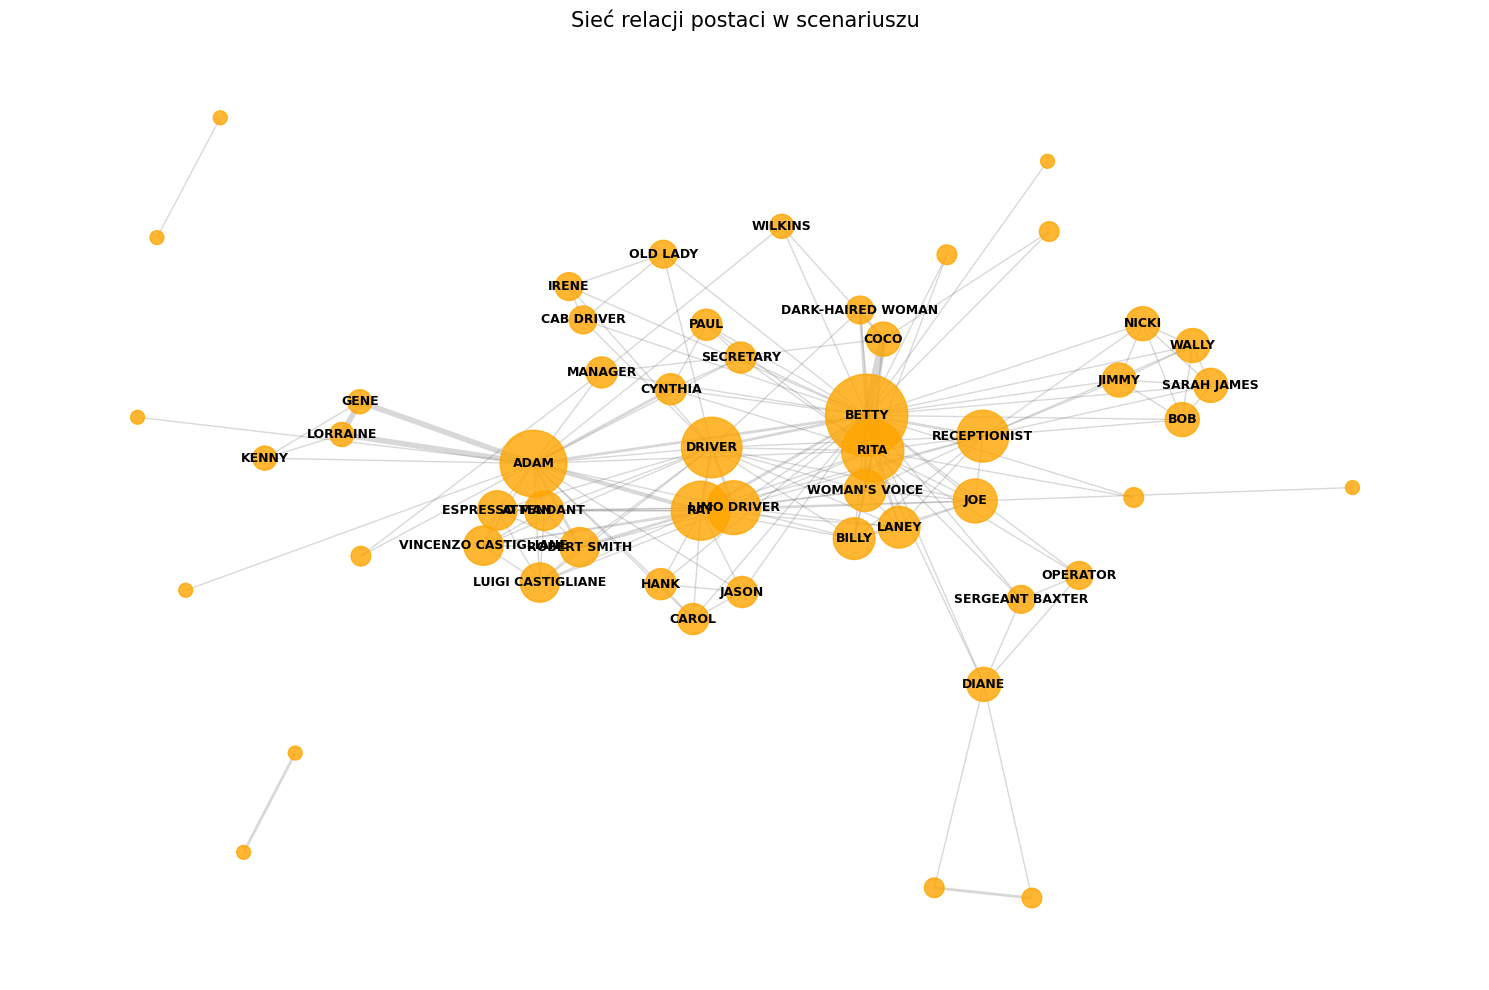

ℹ️ Notatka: Wyświetlono etykiety tylko dla 40 najważniejszych postaci, aby zachować czytelność wykresu.


In [14]:
import matplotlib.pyplot as plt
import networkx as nx

try:
    if 'G_global' not in locals():
        print("❌ Błąd: Sieć nie została zbudowana. Uruchom poprzedni krok.")
    else:
        G = G_global

        # Obliczanie pozycji węzłów (układ sprężynowy)
        pos = nx.spring_layout(G, k=0.5, seed=42)

        # Parametry wizualizacji
        node_degrees = dict(G.degree())
        node_sizes = [v * 100 for v in node_degrees.values()]
        edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

        plt.figure(figsize=(15, 10))

        # Rysowanie krawędzi (grubość zależna od wagi)
        nx.draw_networkx_edges(G, pos, alpha=0.3, width=edge_weights, edge_color='gray')

        # Rysowanie węzłów
        nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='orange', alpha=0.8)

        # Rysowanie etykiet tylko dla postaci z co najmniej 3 połączeniami (dla czytelności)
        labels = {node: node for node, degree in node_degrees.items() if degree >= 3}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold')

        plt.title("Sieć relacji postaci w scenariuszu", fontsize=15)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

        if G.number_of_nodes() > 20:
            print(f"ℹ️ Notatka: Wyświetlono etykiety tylko dla {len(labels)} najważniejszych postaci, aby zachować czytelność wykresu.")

except Exception as e:
    print(f"❌ Wystąpił błąd podczas generowania podglądu sieci: {e}")

#### Po uruchomieniu powinieneś zobaczyć


- Jeden rysunek sieci umieszczony bezpośrednio pod komórką.
- Większą widoczność postaci silniej osadzonych w sieci oraz wyraźniejsze relacje o większej sile.
- Krótką notę wyjaśniającą uproszczenie, jeśli sieć okaże się bardzo gęsta.


#### Pytanie interpretacyjne

Czy na podglądzie widać jednego głównego pośrednika, kilka grup postaci czy raczej gęstą strukturę bez wyraźnego centrum?


### Krok 5C. Eksport danych do dalszej analizy

#### Cel i sens analityczny

Ostatni krok przygotowuje dwa pliki, które można pobrać z Colab i analizować dalej w innych narzędziach.


#### Prompt dla modelu

```text
Kontekst:
Masz gotową tabelę relacji oraz zbudowaną sieć postaci.

Wejście:
Tabela relacji i gotowa sieć.

Zadanie:
Zapisz tabelę relacji do pliku `krawedzie.csv`, a całą sieć do pliku `graf_postaci.graphml`. Na końcu pokaż krótko, jakie pliki powstały i gdzie student może je znaleźć w środowisku notatnika.

Pokaż wynik:
- komunikat o zapisaniu obu plików,
- listę nazw zapisanych plików,
- krótką wskazówkę, jak pobrać je z Colab.

Warunek poprawności:
Oba pliki powinny być niepuste i gotowe do otwarcia poza notatnikiem.

Jeśli wystąpi błąd:
Wyjaśnij, którego pliku nie udało się zapisać i z jakiego powodu.

Nie rób jeszcze:
Nie wykonuj już dalszej analizy.
```


In [15]:
import pandas as pd
import networkx as nx
import os

try:
    if 'tabela_relacji_global' not in locals() or 'G_global' not in locals():
        print("❌ Błąd: Brak danych do eksportu. Upewnij się, że poprzednie kroki zostały wykonane.")
    else:
        # 1. Zapis tabeli relacji do CSV
        df_krawedzie = pd.DataFrame(tabela_relacji_global)
        df_krawedzie.to_csv('krawedzie.csv', index=False, encoding='utf-8')

        # 2. Zapis sieci do GraphML (format czytelny m.in. dla Gephi)
        nx.write_graphml(G_global, 'graf_postaci.graphml')

        print("✅ Pliki zostały pomyślnie zapisane.")
        print("\nLista wygenerowanych plików:")
        print(f"- krawedzie.csv (rozmiar: {os.path.getsize('krawedzie.csv')} bajtów)")
        print(f"- graf_postaci.graphml (rozmiar: {os.path.getsize('graf_postaci.graphml')} bajtów)")

        print("\n💡 Jak pobrać pliki?")
        print("1. Kliknij ikonę folderu w lewym pasku bocznym Colab.")
        print("2. Znajdź pliki na liście.")
        print("3. Kliknij trzy kropki obok nazwy pliku i wybierz 'Pobierz' (Download).")

except Exception as e:
    print(f"❌ Wystąpił błąd podczas zapisywania plików: {e}")

✅ Pliki zostały pomyślnie zapisane.

Lista wygenerowanych plików:
- krawedzie.csv (rozmiar: 3361 bajtów)
- graf_postaci.graphml (rozmiar: 15033 bajtów)

💡 Jak pobrać pliki?
1. Kliknij ikonę folderu w lewym pasku bocznym Colab.
2. Znajdź pliki na liście.
3. Kliknij trzy kropki obok nazwy pliku i wybierz 'Pobierz' (Download).


#### Po uruchomieniu powinieneś zobaczyć


- Potwierdzenie zapisania plików `krawedzie.csv` i `graf_postaci.graphml`.
- Krótką listę lub komunikat pokazujący, że pliki są widoczne w środowisku notatnika.
- Jednozdaniową wskazówkę, jak pobrać pliki z Google Colab.


---
## Co dalej?

- Otwórz `graf_postaci.graphml` w Gephi albo innym narzędziu do analizy sieci, aby policzyć miary centralności i sprawdzić społeczności postaci.
- Otwórz `krawedzie.csv` w arkuszu kalkulacyjnym, jeśli chcesz filtrować, sortować i porównywać relacje bez pracy na grafie.
- Zmień adres scenariusza w komórce parametru i porównaj strukturę narracyjną różnych filmów.
- Jeśli któryś krok działa źle, poproś model o poprawienie tylko tego jednego fragmentu zamiast generowania całego rozwiązania od nowa.
